# Analisis Exploratorio (EDA) con Pandas

Este notebook genera el analisis descriptivo, detecta patrones y resume conclusiones usando el dataset real.

In [8]:
import pandas as pd
from pathlib import Path

candidates = [
    Path("nasa_exoplanet_intelligence_clean.csv"),
    Path("cleandata-ciencia-de-datos") / "nasa_exoplanet_intelligence_clean.csv",
]

DATA_PATH = next((p for p in candidates if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError("No se encontro el archivo nasa_exoplanet_intelligence_clean.csv")

df = pd.read_csv(DATA_PATH)

def find_column(candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

print(df.shape)
df.head()

(6150, 31)


,controversial_flag,dec,disc_facility,disc_year,discovery_method,dist_category,dist_from_earth_pc,equilibrium_temp_k,habitable_zone_flag,host_star,...,ra,semi_major_axis_au,star_age_gyr,star_mass_sun,star_metallicity,star_radius_sun,star_surface_gravity,star_temp_k,star_type,star_vmag
0,0,47.693965,kepler,2016.0,transit,far(500-2kpc),820.905,1419.0,False,kepler-1167,...,298.302660,0.01750,4.27,0.790,-0.05,0.750,4.600,4971.0,k-type,16.0470
1,0,38.922455,kepler,2021.0,transit,far(500-2kpc),1061.770,858.0,False,kepler-1740,...,293.873663,0.07790,NaN,0.943,-0.06,0.905,4.499,5705.0,g-type(sun-like),15.4540
2,0,39.603623,kepler,2016.0,transit,mid(100-500pc),493.175,1108.0,False,kepler-1581,...,287.371320,0.06865,4.17,1.120,0.07,1.230,4.310,6022.0,f-type,12.4420
3,0,43.493112,kepler,2016.0,transit,far(500-2kpc),1318.050,1655.0,False,kepler-644,...,295.475702,0.04641,1.62,1.490,0.08,1.810,4.090,6747.0,f-type,14.0310
4,0,51.222743,kepler,2021.0,transit,far(500-2kpc),962.888,419.0,False,kepler-1752,...,290.854140,0.26980,7.20,0.824,-0.20,0.821,4.525,5446.0,g-type(sun-like),16.0249


## 1. Analisis Descriptivo

Empezamos con informacion general: cantidad de registros, variables y periodo de descubrimiento (si el campo esta disponible).

In [2]:
records, variables = df.shape

year_col = find_column([
    "discovery_year",
    "disc_year",
    "discovered_year",
    "year",
    "discovery_date_year",
])

if year_col is not None:
    year_min = int(df[year_col].min())
    year_max = int(df[year_col].max())
else:
    year_min = None
    year_max = None

info = {
    "records": records,
    "variables": variables,
    "year_col": year_col,
    "year_min": year_min,
    "year_max": year_max,
}

info

{'records': 6150,
 'variables': 31,
 'year_col': 'disc_year',
 'year_min': 1992,
 'year_max': 2026}

La salida anterior muestra el tamano del dataset y el periodo de descubrimiento si existe una columna de anio. Con eso ya tenemos el resumen general.

### Valores faltantes

Calculamos los faltantes para identificar variables con menor cobertura.

In [3]:
missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)
missing.head(10)

equilibrium_temp_k      1563
star_age_gyr            1311
orbital_eccentricity     938
star_metallicity         550
orbital_period_days      334
star_surface_gravity     318
semi_major_axis_au       316
star_radius_sun          314
star_vmag                295
star_temp_k              290
dtype: int64

Las variables en el top del ranking son las que limitan analisis mas completos de propiedades fisicas.

### Metodos de descubrimiento

Contamos la frecuencia de los metodos para ver que tecnicas dominan el dataset.

In [10]:
method_candidates = [
    "discovery_method",
    "method",
    "detection_method",
]

method_col = find_column(method_candidates)

if method_col is None:
    method_like = [c for c in df.columns if "method" in c.lower()]
    print("Candidatas encontradas:", method_like)
else:
    method_counts = df[method_col].value_counts()
    display(method_counts)

discovery_method
transit                          4517
radial velocity                  1182
microlensing                      275
imaging                            94
transit timing variations          39
eclipse timing variations          17
orbital brightness modulation       9
pulsar timing                       8
astrometry                          6
pulsation timing variations         2
disk kinematics                     1
Name: count, dtype: int64

Si el metodo Transit aparece como el mas frecuente, confirma el predominio de ese enfoque de deteccion.

### Tipos de estrellas hospedadoras

Revisamos la distribucion de tipos de estrellas para entender el sesgo del muestreo.

In [11]:
star_type_col = find_column([
    "star_type",
    "host_star_type",
    "stellar_type",
    "spectral_type",
    "star_spectral_type",
])

if star_type_col is not None:
    star_type_counts = df[star_type_col].value_counts()
    display(star_type_counts)
else:
    print("No se encontró columna de tipo estelar.")

star_type
g-type(sun-like)     2669
k-type               1644
f-type               1075
m-type(red dwarf)     423
unknown               290
a-type                 25
b-type                 19
o-type                  5
Name: count, dtype: int64

Si los tipos G y K lideran, el dataset esta sesgado hacia estrellas similares al Sol.

### Zona habitable

Contamos cuantos exoplanetas estan dentro de la zona habitable.

In [12]:
habitable_col = find_column([
    "habitable_zone_flag",
    "habitable",
    "habitable_zone",
    "in_habitable_zone",
    "habitable_flag",
])

if habitable_col is not None:
    habitable_counts = df[habitable_col].value_counts(dropna=False)
    display(habitable_counts)
else:
    print("No se encontró columna de zona habitable.")

habitable_zone_flag
False    5747
True      403
Name: count, dtype: int64

Esto permite estimar la proporcion de candidatos potencialmente habitables.

## 2. Deteccion de Patrones

Buscamos correlaciones y relaciones entre variables clave.

In [13]:
def corr_if_available(col_a, col_b):
    if col_a in df.columns and col_b in df.columns:
        return df[[col_a, col_b]].corr().iloc[0, 1]
    return None

corr_orbital = corr_if_available(
    "orbital_period_days",
    "semi_major_axis_au"
)

corr_mass_radius = corr_if_available(
    "planet_mass_earth",
    "planet_radius_earth"
)

corr_dist_vmag = corr_if_available(
    "dist_from_earth_pc",
    "star_vmag"
)

correlations = {
    "Periodo orbital vs distancia orbital": corr_orbital,
    "Masa vs radio planetario": corr_mass_radius,
    "Distancia vs magnitud visual": corr_dist_vmag,
}

display(pd.Series(correlations))

Periodo orbital vs distancia orbital    0.996707
Masa vs radio planetario                0.454087
Distancia vs magnitud visual            0.605823
dtype: float64

Si las correlaciones son altas, refuerzan relaciones fisicas esperadas (por ejemplo, periodo orbital y distancia al astro).

## Graficos recomendados

Estos tres graficos ayudan a reforzar el analisis descriptivo y la deteccion de patrones.

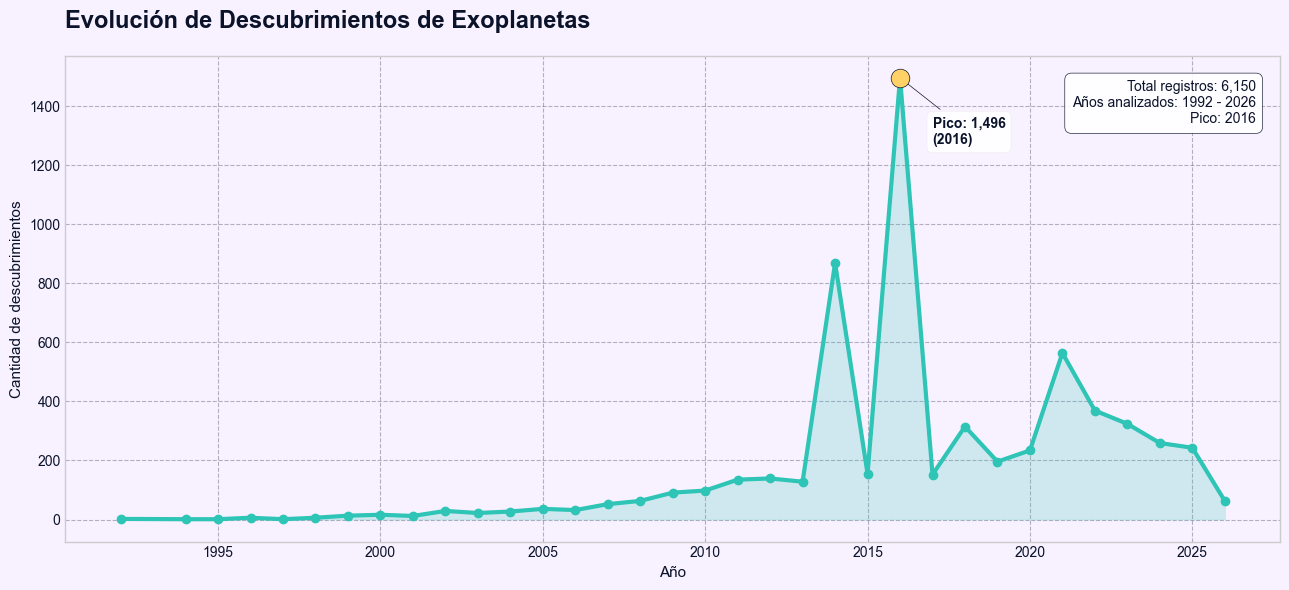

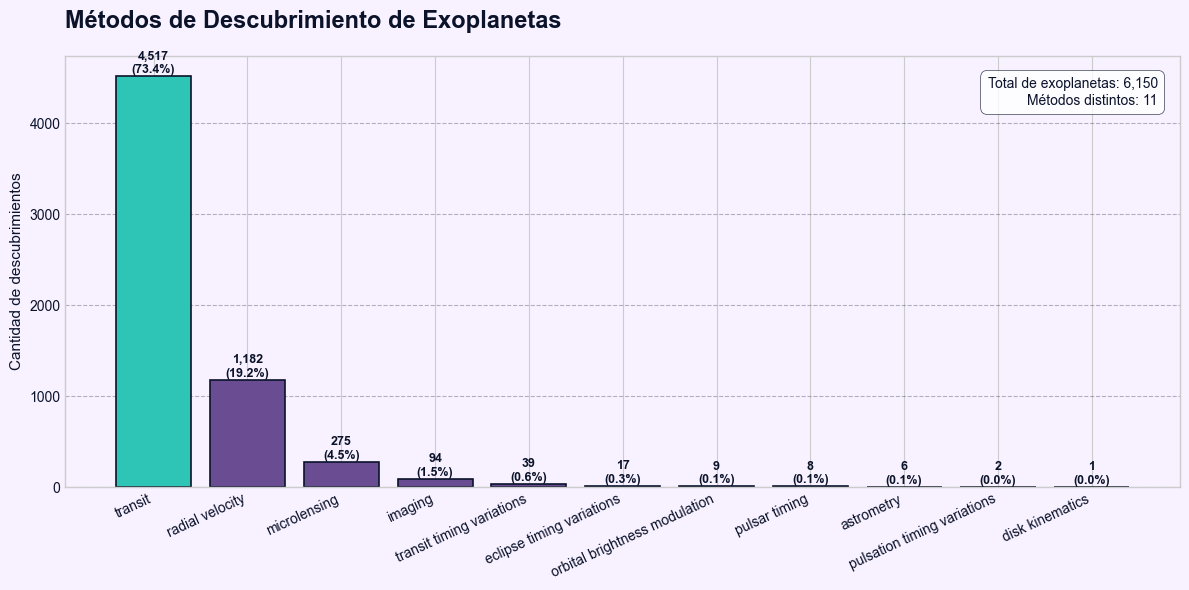

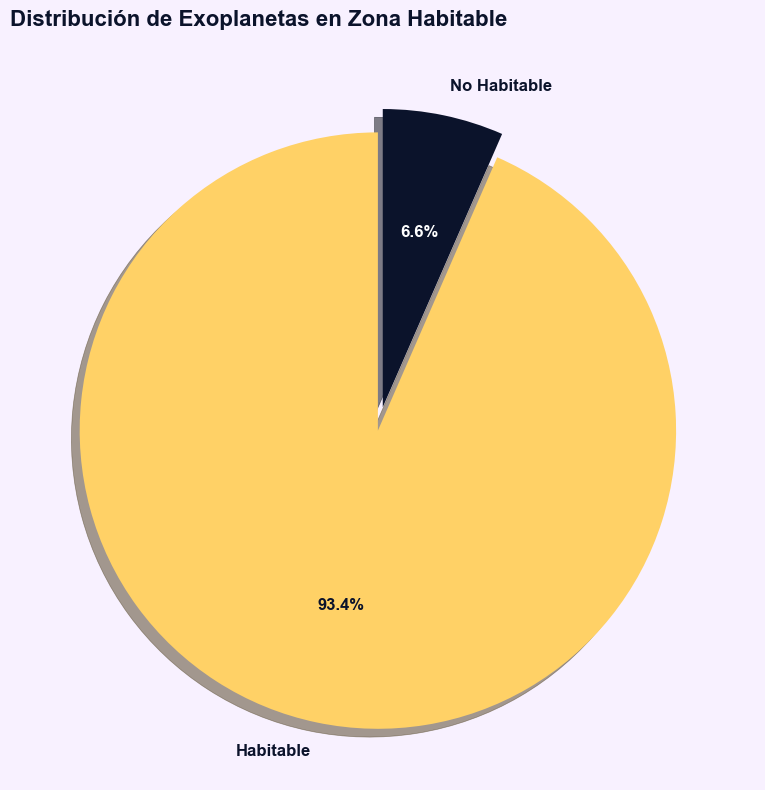

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Estilo general
plt.style.use("seaborn-v0_8-whitegrid")

# Paleta tematica astronomia (alto contraste)
COLOR_STAR = "#FFD166"  # dorado claro
COLOR_NEBULA = "#6A4C93"  # violeta intenso
COLOR_SPACE = "#0B132B"  # azul muy oscuro
COLOR_AURORA = "#2EC4B6"  # turquesa brillante
COLOR_DUST = "#F8F1FF"  # fondo claro

# ----------------------------
# GRAFICO 1 - Descubrimientos por año
# ----------------------------

year_plot_col = year_col or find_column([
    "disc_year",
    "discovery_year",
    "year"
])

if year_plot_col is not None:

    discoveries = df[year_plot_col].value_counts().sort_index()
    discoveries.index = discoveries.index.astype(int)

    peak_year = discoveries.idxmax()
    peak_value = discoveries.max()

    fig, ax = plt.subplots(
        figsize=(13, 6),
        facecolor=COLOR_DUST
    )

    ax.set_facecolor(COLOR_DUST)

    ax.plot(
        discoveries.index,
        discoveries.values,
        marker="o",
        linewidth=3,
        markersize=6,
        color=COLOR_AURORA,
        label="Descubrimientos"
    )

    ax.fill_between(
        discoveries.index,
        discoveries.values,
        alpha=0.20,
        color=COLOR_AURORA
    )

    # Resaltar el máximo
    ax.scatter(
        peak_year,
        peak_value,
        s=180,
        color=COLOR_STAR,
        edgecolor=COLOR_SPACE,
        zorder=5
    )

    ax.annotate(
        f"Pico: {peak_value:,}\n({peak_year})",
        xy=(peak_year, peak_value),
        xytext=(peak_year + 1, peak_value * 0.85),
        fontsize=10,
        fontweight="bold",
        color=COLOR_SPACE,
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            alpha=0.9
        ),
        arrowprops=dict(
            arrowstyle="->",
            color=COLOR_SPACE
        )
    )

    ax.set_title(
        "Evolución de Descubrimientos de Exoplanetas",
        fontsize=17,
        fontweight="bold",
        color=COLOR_SPACE,
        loc="left",
        pad=20
    )

    ax.set_ylabel(
        "Cantidad de descubrimientos",
        fontsize=11,
        color=COLOR_SPACE
    )

    ax.set_xlabel(
        "Año",
        fontsize=11,
        color=COLOR_SPACE
    )

    ax.tick_params(axis="x", colors=COLOR_SPACE)
    ax.tick_params(axis="y", colors=COLOR_SPACE)

    ax.grid(
        linestyle="--",
        alpha=0.3,
        color=COLOR_SPACE
    )

    # Caja resumen
    ax.text(
        0.98,
        0.95,
        f"Total registros: {len(df):,}\n"
        f"Años analizados: {discoveries.index.min()} - {discoveries.index.max()}\n"
        f"Pico: {peak_year}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        color=COLOR_SPACE,
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            edgecolor=COLOR_SPACE,
            alpha=0.9
        )
    )

    plt.tight_layout()
    plt.show()

else:
    print("No se encontró columna de año.")

# ----------------------------
# GRAFICO 2 - Métodos de descubrimiento
# ----------------------------

method_plot_col = method_col or find_column([
    "discovery_method",
    "method",
    "detection_method"
])

if method_plot_col is not None:

    counts = df[method_plot_col].value_counts()

    fig, ax = plt.subplots(
        figsize=(12, 6),
        facecolor=COLOR_DUST
    )

    ax.set_facecolor(COLOR_DUST)

    # Resaltar el método más utilizado
    colors = [COLOR_AURORA] + [COLOR_NEBULA] * (len(counts) - 1)

    bars = ax.bar(
        counts.index,
        counts.values,
        color=colors,
        edgecolor=COLOR_SPACE,
        linewidth=1.2
    )

    ax.set_title(
        "Métodos de Descubrimiento de Exoplanetas",
        fontsize=17,
        fontweight="bold",
        color=COLOR_SPACE,
        loc="left",
        pad=20
    )

    ax.set_ylabel(
        "Cantidad de descubrimientos",
        fontsize=11,
        color=COLOR_SPACE
    )

    ax.set_xlabel("")

    ax.tick_params(axis="x", colors=COLOR_SPACE)
    ax.tick_params(axis="y", colors=COLOR_SPACE)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3,
        color=COLOR_SPACE
    )

    total = counts.sum()

    # Cantidad y porcentaje encima de cada barra
    for bar in bars:

        height = bar.get_height()
        percentage = (height / total) * 100

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:,}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color=COLOR_SPACE
        )

    # Caja de resumen
    ax.text(
        0.98,
        0.95,
        f"Total de exoplanetas: {total:,}\nMétodos distintos: {len(counts)}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        color=COLOR_SPACE,
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            alpha=0.8,
            edgecolor=COLOR_SPACE
        )
    )

    plt.xticks(rotation=25, ha="right")

    plt.tight_layout()
    plt.show()

else:
    print("No se encontró columna de método.")

# ----------------------------
# GRAFICO 3 - Zona habitable
# ----------------------------

habitable_plot_col = habitable_col or find_column([
    "habitable_zone_flag",
    "habitable",
    "habitable_zone"
])

if habitable_plot_col is not None:

    counts = df[habitable_plot_col].value_counts()

    fig, ax = plt.subplots(
        figsize=(8, 8),
        facecolor=COLOR_DUST
    )

    ax.set_facecolor(COLOR_DUST)

    colors = [COLOR_STAR, COLOR_SPACE]

    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=["Habitable", "No Habitable"],
        autopct="%1.1f%%",
        startangle=90,
        explode=[0.08] + [0] * (len(counts) - 1),
        shadow=True,
        colors=colors[:len(counts)]
    )

    # Personalizar etiquetas
    for text in texts:
        text.set_fontsize(12)
        text.set_fontweight("bold")
        text.set_color(COLOR_SPACE)

    # Personalizar porcentajes
    for i, autotext in enumerate(autotexts):
        autotext.set_fontsize(12)
        autotext.set_fontweight("bold")

        if i == 0:
            autotext.set_color(COLOR_SPACE)
        else:
            autotext.set_color("white")

    ax.set_title(
        "Distribución de Exoplanetas en Zona Habitable",
        fontsize=16,
        fontweight="bold",
        color=COLOR_SPACE,
        loc="left"
    )

    plt.tight_layout()
    plt.show()

else:
    print("No se encontró columna de zona habitable.")

## 3. Primeras Conclusiones

El análisis exploratorio permitió obtener una visión general del conjunto de datos de exoplanetas y comprender mejor su estructura y características principales. El dataset analizado contiene miles de registros correspondientes a descubrimientos realizados entre 1992 y 2026, lo que proporciona una muestra amplia para el estudio de sistemas planetarios fuera del Sistema Solar.

Durante el análisis descriptivo se identificó la presencia de valores faltantes en diversas variables físicas, como la temperatura de equilibrio, la edad de la estrella anfitriona y la excentricidad orbital. Esto indica que no todos los exoplanetas cuentan con información completa, situación habitual en bases de datos astronómicas debido a las limitaciones observacionales y tecnológicas.

En relación con los métodos de descubrimiento, se observó un claro predominio del método Transit, que concentra la mayor parte de los registros analizados. Este comportamiento evidencia la influencia de misiones espaciales especializadas, como Kepler y TESS, en la generación de datos astronómicos durante las últimas décadas.

Por otra parte, el análisis de correlaciones permitió identificar relaciones consistentes con principios físicos conocidos. Destaca especialmente la fuerte asociación entre el período orbital y la distancia al astro anfitrión, así como una relación positiva entre la masa y el radio planetario. Estos resultados aportan confianza en la calidad y coherencia de los datos utilizados.

Finalmente, se comprobó que la cantidad de exoplanetas ubicados dentro de la zona habitable representa una proporción reducida respecto del total registrado. Este hallazgo refuerza el interés científico que despiertan estos candidatos, ya que podrían presentar condiciones favorables para la existencia de agua líquida y, potencialmente, de vida.

En conjunto, los resultados obtenidos permiten identificar tendencias relevantes, validar relaciones esperadas desde el punto de vista astronómico y establecer una base sólida para futuros análisis más avanzados sobre el comportamiento y las características de los exoplanetas.